In [1]:
using SolidStateDetectors
using Unitful
using Plots; 

In [2]:
sim = Simulation(SSD_examples[:IVCIlayer])
sim.detector = SolidStateDetector(sim.detector, contact_id = 2, contact_potential =500u"V")

________Public Inverted Coax Inactive________

---General Properties---
- Precision type: Float32

	_____Semiconductor_____

Semiconductor{Float32} - High Purity Germanium

# Contacts: 2
Contact 1 - 0.0 V - High Purity Germanium
Contact 2 - 500.0 V - High Purity Germanium

# Passives: 1
Passive Passivation Layer - id -1 - NaN V


### Inizializzazione dello stato

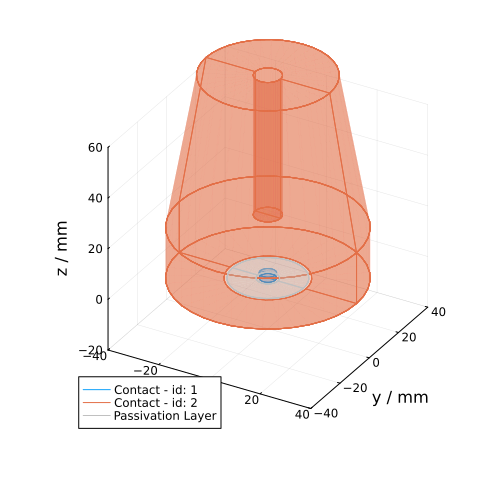

In [3]:
plot(sim.detector, size = (500,500), 
    xunit = u"mm", yunit = u"mm", zunit = u"mm", xlims = (-40,40), ylims = (-40,40), zlims = (-20,60))

apply initial state : update `sim.electric_potential`, `sim.q_eff_imp`, `sim.q_eff_fix`, `sim.ϵ` and `sim.point_types`


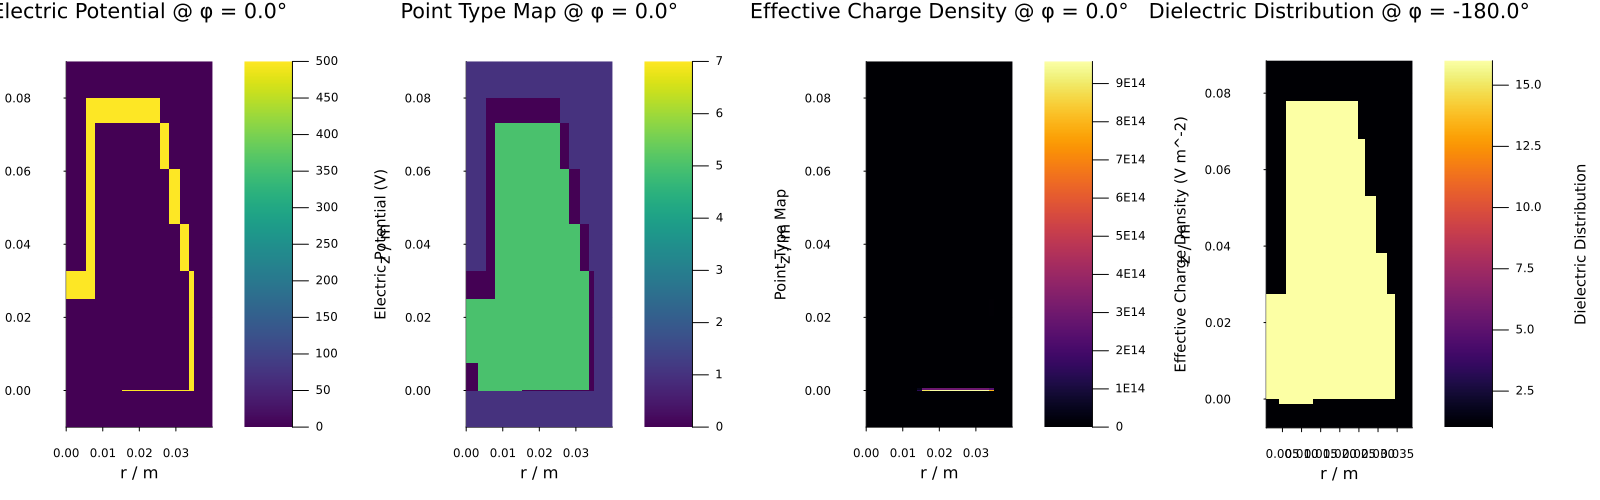

In [4]:

apply_initial_state!(sim, ElectricPotential) # optional
plot(
    plot(sim.electric_potential), # initial electric potential (boundary conditions)
    plot(sim.point_types), # map of different point types: fixed point / inside or outside detector volume / depleted/undepleted
    plot(sim.q_eff_imp), # charge density distribution
    plot(sim.ϵ_r), # dielectric distribution
    layout = (1, 4), size = (1600, 500)
)

In [5]:
SolidStateDetectors.update_till_convergence!(sim, ElectricPotential, depletion_handling=true)
# quello che restituisce la funzione è l'errore al quale il loop si blocca

3.0517578f-5

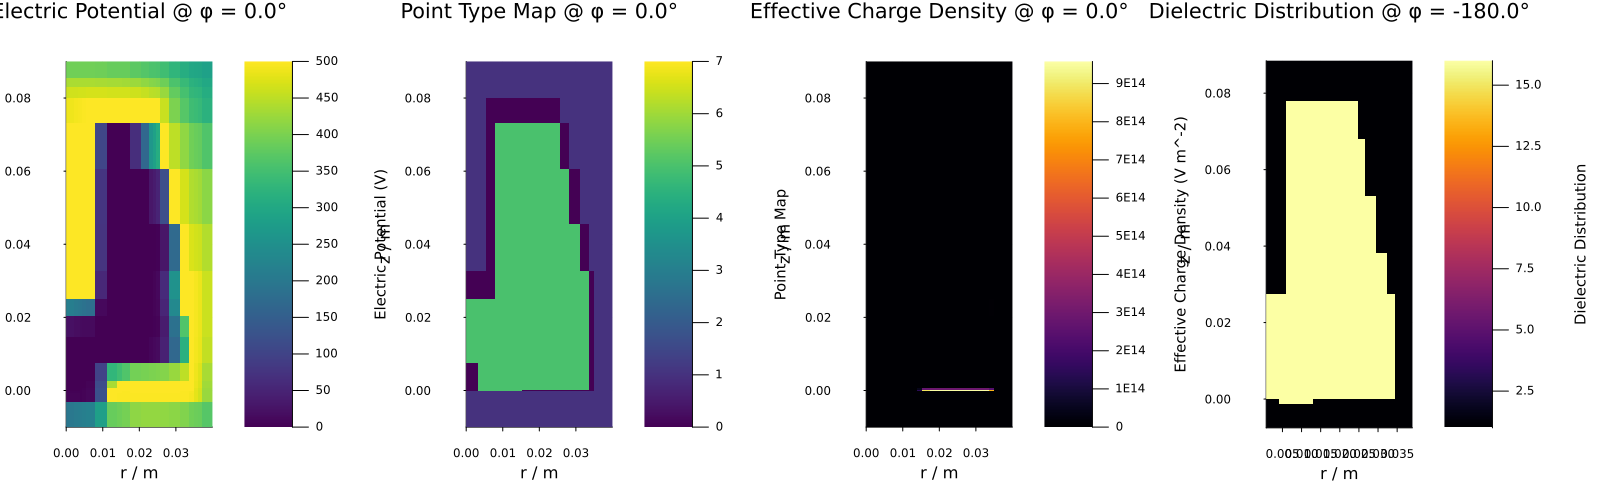

In [6]:

plot(
    plot(sim.electric_potential, φ = 0), # uupdated electric potential 
    plot(sim.point_types), # map of different point types: fixed point / inside or outside detector volume / depleted/undepleted
    plot(sim.q_eff_imp), # charge density distribution
    plot(sim.ϵ_r), # dielectric distribution
    layout = (1, 4), size = (1600, 500)
)

## Refinement

In [7]:
ref_limits = 0.2
bias_voltage = 500
max_diff = abs.(ref_limits .* bias_voltage)
max_diff_array = (max_diff, max_diff, max_diff)

(100.0, 100.0, 100.0)

In [8]:
SolidStateDetectors.refine!(sim, ElectricPotential, max_diff_array  )

In [9]:
sim.electric_potential.grid

Grid{Float32, 3, Cylindrical}(0.0 .. 0.04 - length = 40, 0.0 .. 0.0 - length = 1, -0.01 .. 0.09 - length = 42)

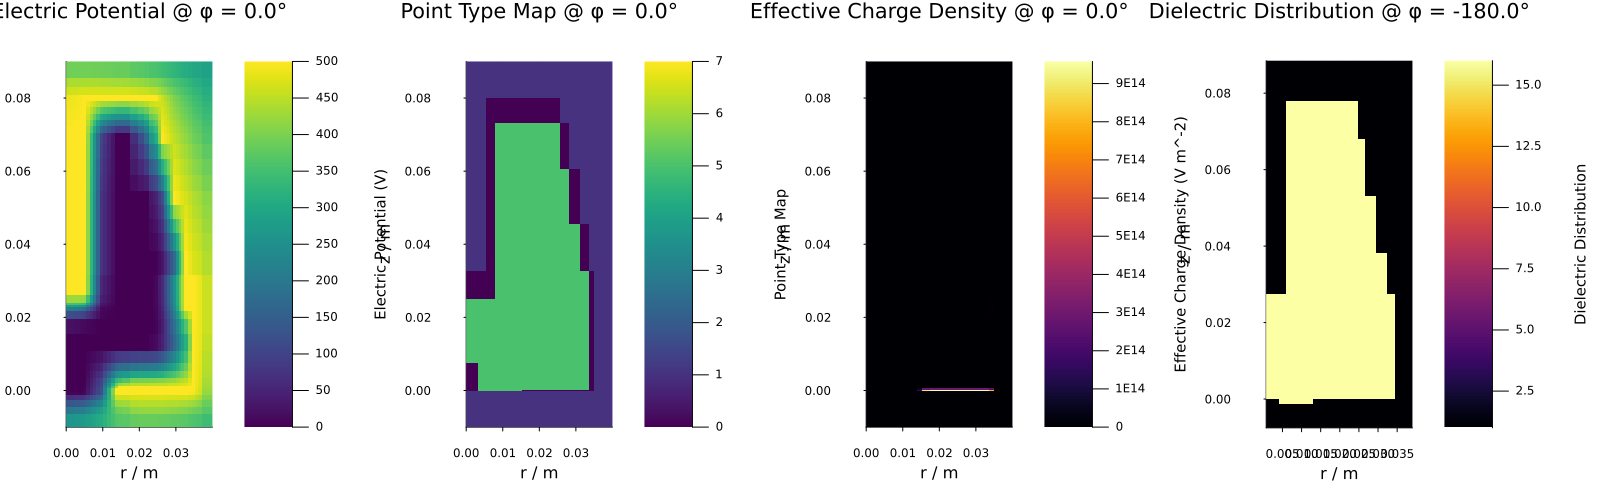

In [10]:

plot(
    plot(sim.electric_potential, φ = 0), # uupdated electric potential 
    plot(sim.point_types), # map of different point types: fixed point / inside or outside detector volume / depleted/undepleted
    plot(sim.q_eff_imp), # charge density distribution
    plot(sim.ϵ_r), # dielectric distribution
    layout = (1, 4), size = (1600, 500)
)
# vinee fatto il reifnement solo del potenziale elettrico

rifaccio un altro reifnement

In [11]:
ref_limits = 0.1
bias_voltage = 500
max_diff = abs.(ref_limits .* bias_voltage)
max_diff_array = (max_diff, max_diff, max_diff)

(50.0, 50.0, 50.0)

In [12]:
SolidStateDetectors.refine!(sim, ElectricPotential, max_diff_array  )

In [13]:
sim.electric_potential.grid

Grid{Float32, 3, Cylindrical}(0.0 .. 0.04 - length = 66, 0.0 .. 0.0 - length = 1, -0.01 .. 0.09 - length = 78)

### dopo aver fatto il reifnement devo anche applicare nuovamente update_till_convergence che ci da anche i nuovi valori aggiornati della scala di densità, dell apermittività elettrica e anche della densità di impurità.

### Inoltre, una volta che i valori del potenziale elettrico/pesato sono interpolati non rappresentano più la corretta soluzione di SOR con la nuova griglia, quindi ho comunque bisogno di far riconvergere per ottenere le corrette soluzioni

In [14]:
SolidStateDetectors.update_till_convergence!(sim, ElectricPotential, depletion_handling=true)

9.1552734f-5

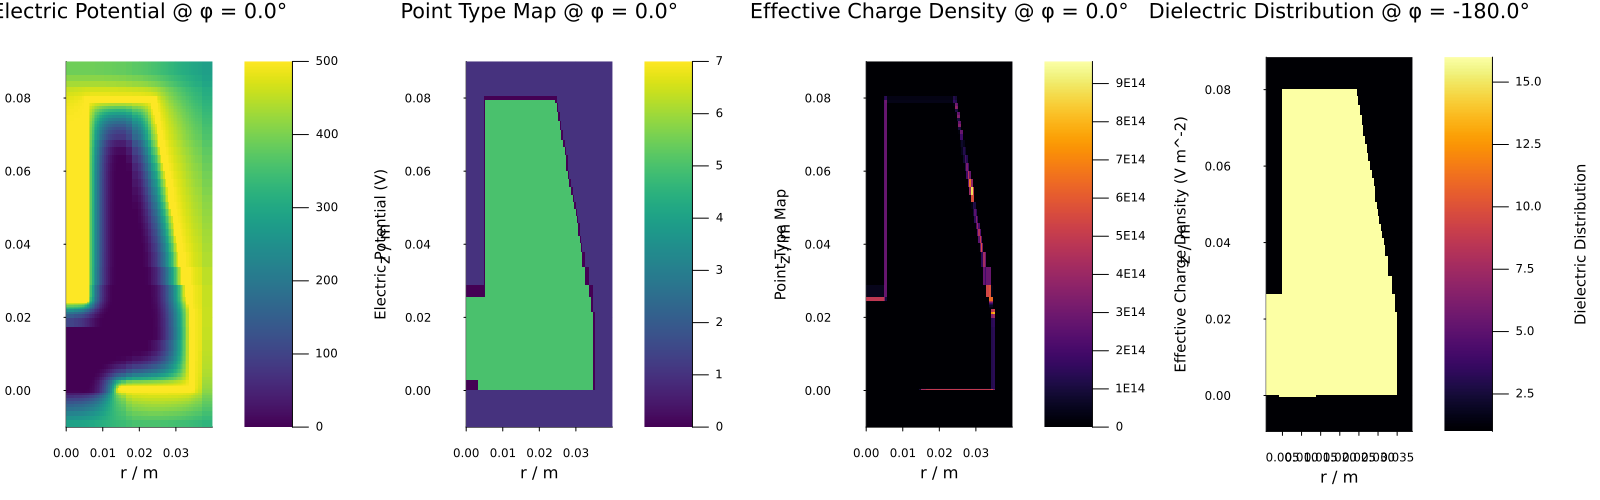

In [15]:

plot(
    plot(sim.electric_potential, φ = 0), # uupdated electric potential 
    plot(sim.point_types), # map of different point types: fixed point / inside or outside detector volume / depleted/undepleted
    plot(sim.q_eff_imp), # charge density distribution
    plot(sim.ϵ_r), # dielectric distribution
    layout = (1, 4), size = (1600, 500)
)
# vinee fatto il reifnement solo del potenziale elettrico

## Provare ad aumentare a mano la griglia

In [19]:
new_grid = Grid(sim, max_tick_distance=0.5u"mm")


Grid{Float32, 3, Cylindrical}(0.0 .. 0.04 - length = 94, 0.0 .. 0.0 - length = 1, -0.01 .. 0.09 - length = 210)

In [23]:
apply_initial_state!(sim, ElectricPotential, new_grid) # optional


apply initial state : update `sim.electric_potential`, `sim.q_eff_imp`, `sim.q_eff_fix`, `sim.ϵ` and `sim.point_types`


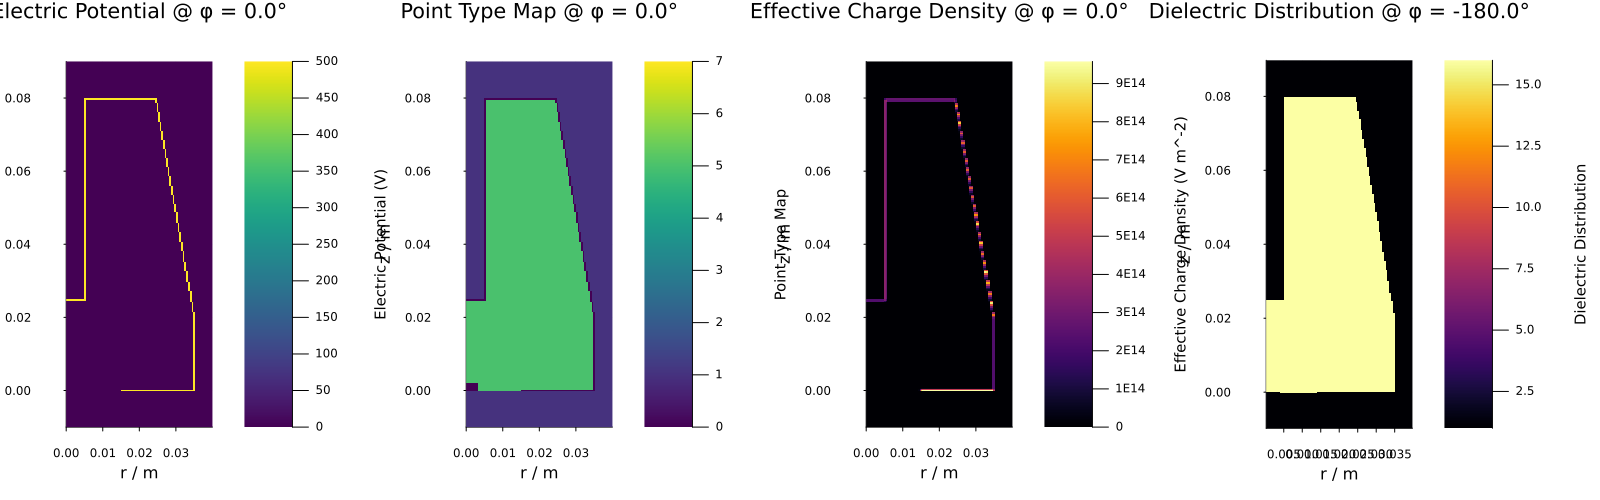

In [24]:
plot(
    plot(sim.electric_potential), # initial electric potential (boundary conditions)
    plot(sim.point_types), # map of different point types: fixed point / inside or outside detector volume / depleted/undepleted
    plot(sim.q_eff_imp), # charge density distribution
    plot(sim.ϵ_r), # dielectric distribution
    layout = (1, 4), size = (1600, 500)
)

In [26]:
SolidStateDetectors.update_till_convergence!(sim, ElectricPotential, depletion_handling=true)

0.00015258789f0

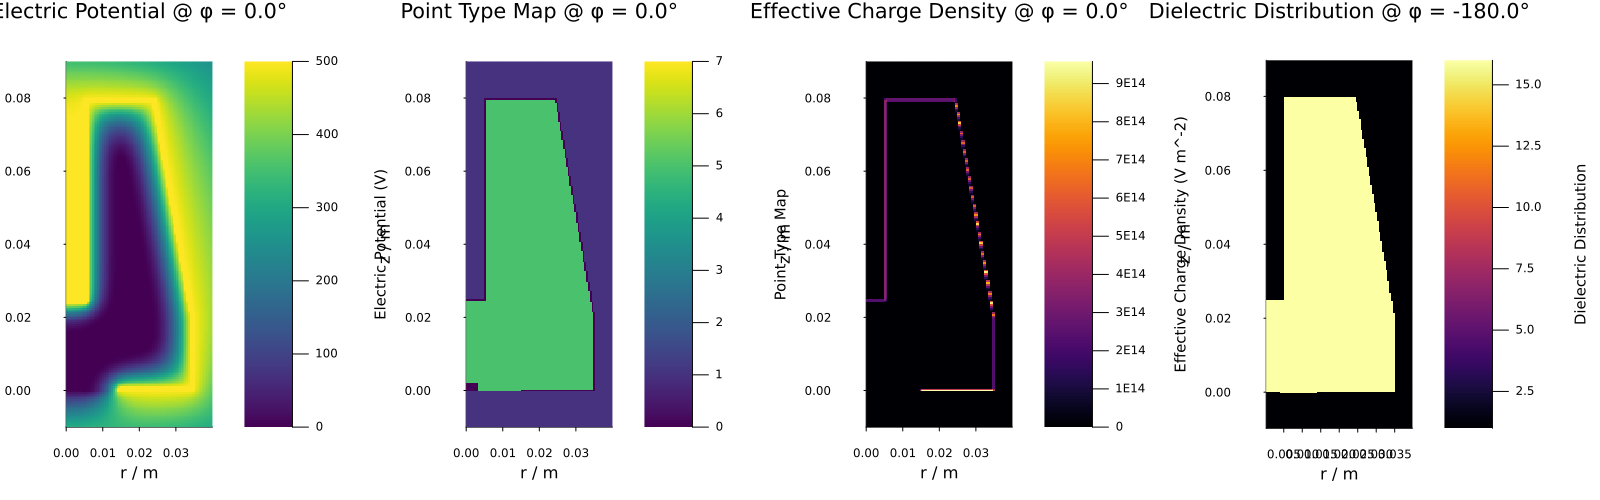

In [27]:
plot(
    plot(sim.electric_potential, φ = 0), # uupdated electric potential 
    plot(sim.point_types), # map of different point types: fixed point / inside or outside detector volume / depleted/undepleted
    plot(sim.q_eff_imp), # charge density distribution
    plot(sim.ϵ_r), # dielectric distribution
    layout = (1, 4), size = (1600, 500)
)

In [29]:
## reifnement after new grid
ref_limits = 0.2
bias_voltage = 500
max_diff = abs.(ref_limits .* bias_voltage)
max_diff_array = (max_diff, max_diff, max_diff)

(100.0, 100.0, 100.0)

In [30]:
SolidStateDetectors.refine!(sim, ElectricPotential, max_diff_array  )

In [31]:
sim.electric_potential.grid

Grid{Float32, 3, Cylindrical}(0.0 .. 0.04 - length = 96, 0.0 .. 0.0 - length = 1, -0.01 .. 0.09 - length = 212)

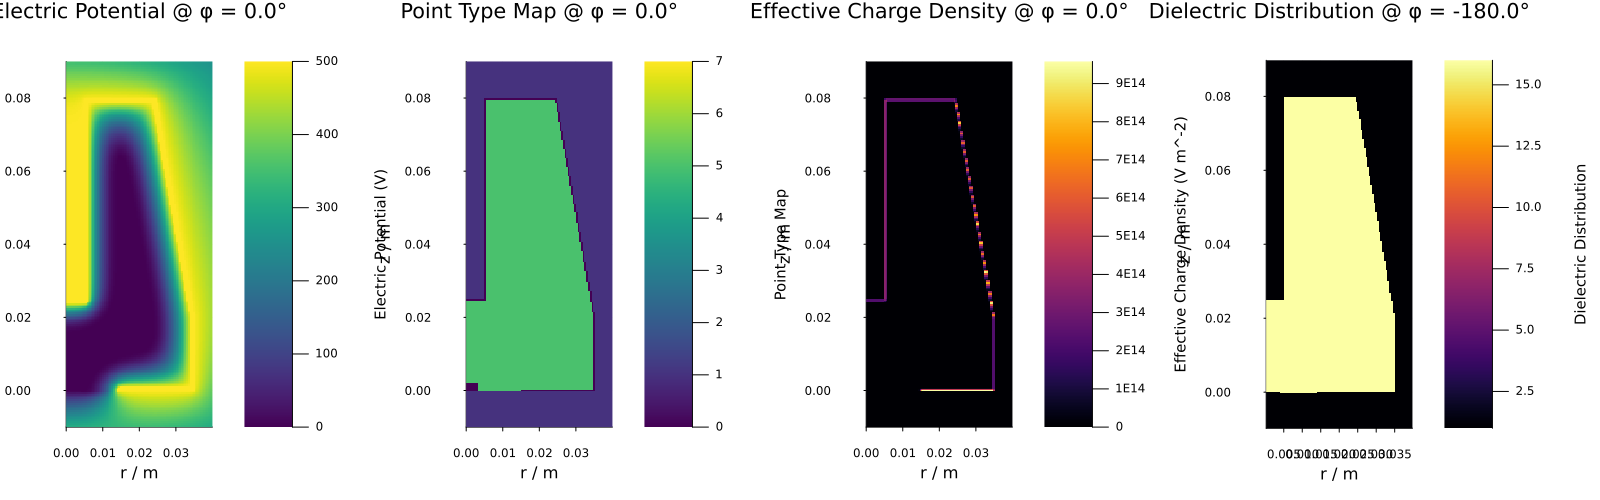

In [32]:

plot(
    plot(sim.electric_potential, φ = 0), # uupdated electric potential 
    plot(sim.point_types), # map of different point types: fixed point / inside or outside detector volume / depleted/undepleted
    plot(sim.q_eff_imp), # charge density distribution
    plot(sim.ϵ_r), # dielectric distribution
    layout = (1, 4), size = (1600, 500)
)
# vinee fatto il reifnement solo del potenziale elettrico

In [33]:
SolidStateDetectors.update_till_convergence!(sim, ElectricPotential, depletion_handling=true)

9.1552734f-5

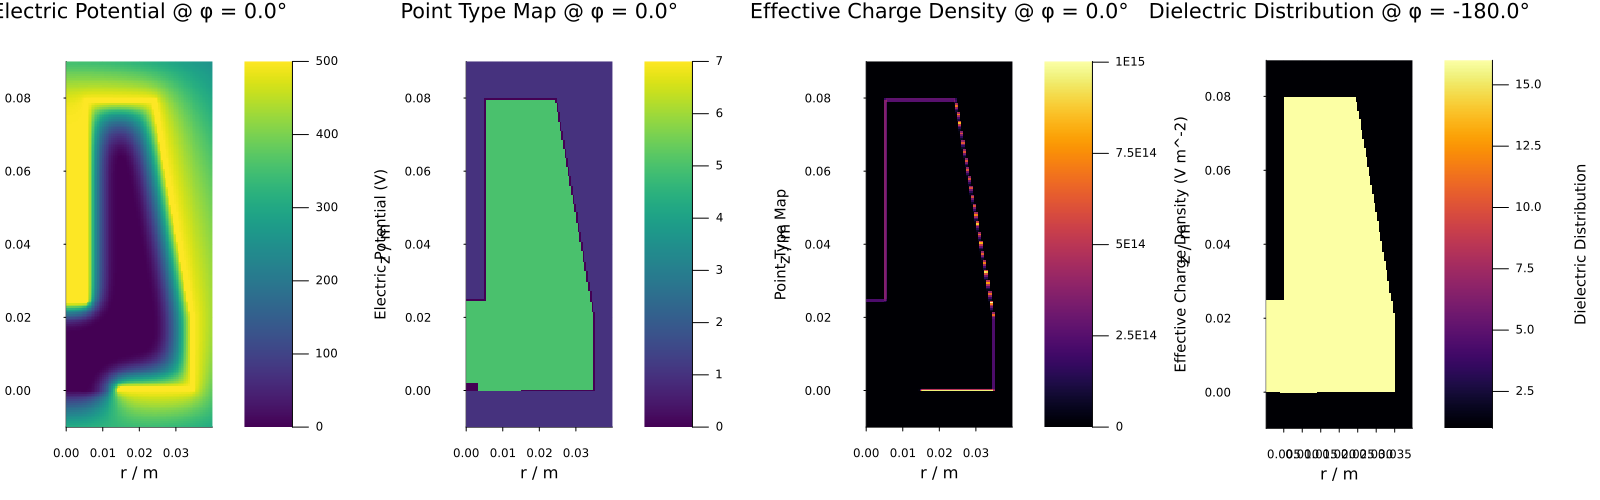

In [34]:

plot(
    plot(sim.electric_potential, φ = 0), # uupdated electric potential 
    plot(sim.point_types), # map of different point types: fixed point / inside or outside detector volume / depleted/undepleted
    plot(sim.q_eff_imp), # charge density distribution
    plot(sim.ϵ_r), # dielectric distribution
    layout = (1, 4), size = (1600, 500)
)
# vinee fatto il reifnement solo del potenziale elettrico

In [35]:
new_grid = Grid(sim, max_tick_distance=0.3u"mm")


Grid{Float32, 3, Cylindrical}(0.0 .. 0.04 - length = 144, 0.0 .. 0.0 - length = 1, -0.01 .. 0.09 - length = 344)

In [36]:
apply_initial_state!(sim, ElectricPotential, new_grid) # optional


apply initial state : update `sim.electric_potential`, `sim.q_eff_imp`, `sim.q_eff_fix`, `sim.ϵ` and `sim.point_types`


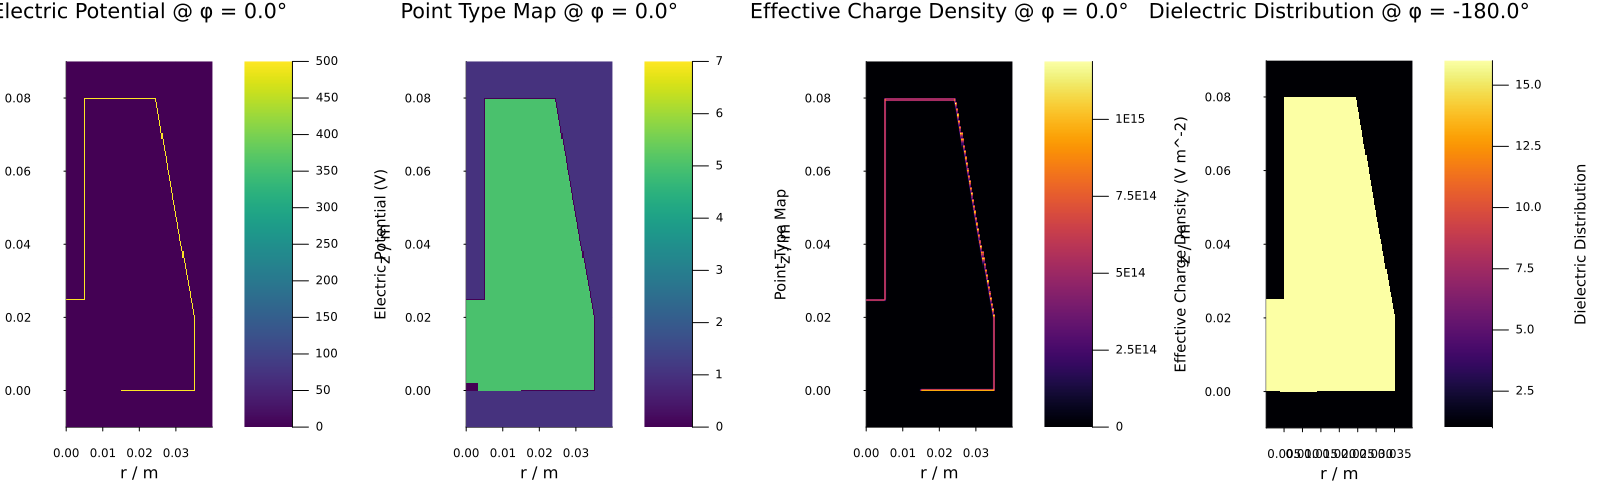

In [37]:
plot(
    plot(sim.electric_potential), # initial electric potential (boundary conditions)
    plot(sim.point_types), # map of different point types: fixed point / inside or outside detector volume / depleted/undepleted
    plot(sim.q_eff_imp), # charge density distribution
    plot(sim.ϵ_r), # dielectric distribution
    layout = (1, 4), size = (1600, 500)
)

In [38]:
SolidStateDetectors.update_till_convergence!(sim, ElectricPotential, depletion_handling=true)

0.00045776367f0

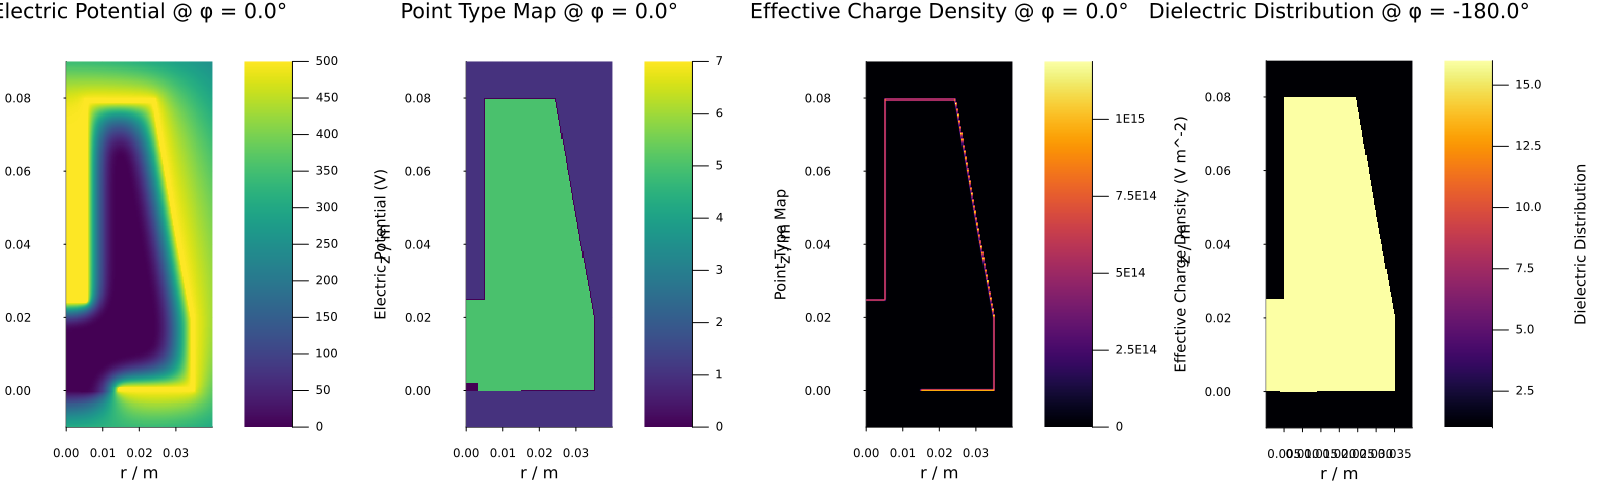

In [39]:
plot(
    plot(sim.electric_potential, φ = 0), # uupdated electric potential 
    plot(sim.point_types), # map of different point types: fixed point / inside or outside detector volume / depleted/undepleted
    plot(sim.q_eff_imp), # charge density distribution
    plot(sim.ϵ_r), # dielectric distribution
    layout = (1, 4), size = (1600, 500)
)